## Chatbot with Profile Schema & LongTerm Memory and HOt-Path writing

### Review:
- we built a chatbot with both chekpointer (withing thread) session based memory and store (across thread) long term mmeory agents previously
- agent saved semantic memory(facts and information or general knowlege ) about the user in the store
- we learnt to define namespace and use get and put methods to interact with the store.
- get - get memory
- put - write to the store
- memory was stored `in the hot path` as user was chatting or interactivng with it

### Goal: Chatbot storeing memory in a sturctured manner
- previously we stored the memory as a string seperated by comma
- In practice , memory must have structure which makes them easy to access and use
### Objective:
- Build a chatbot that saves semantic memory of the user in a **single user profile.**
- use **library and trustcall** to update the schema with new information

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

#Load lang graph tracing api
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [2]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [3]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-3.1-flash-lite" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHbdOIF7iO68p9pH9m4JXHB04hwP36PHC38LxNa/dRiSVV5Oj/IuKGscVZqHxg'}}]

## Profile Schema
-Python has many different types for **structured data, such as TypedDict, Dictionaries, JSON, and Pydantic.**
- Use TypeDict for structured output

#### You are creating an instance of the UserProfile type.

✔ A type = the blueprint
UserProfile (your TypedDict) defines:
- what fields exist
- what types those fields must have
- It’s like a schema.

✔ An instance = a real object created from that blueprint
- user_profile is the actual data object that follows the schema.

TypedDict : “Here is what a user profile should look like.”

Instance : “Here is one actual user profile.”

TypedDict instances are used for:
- state objects
- memory stores
- tool inputs
- structured outputs
- agent context
They help ensure your data is predictable and type‑safe.

In [4]:
from typing_extensions import TypedDict , List


# create a class blue print schema for user profile
class Userprofile(TypedDict, total =False):
    user_name : str
    age:int
    interests:List[str] # list of user interests
    additional_info: dict[str, str]   # <— catch‑all bucket # in case of additional information

    
# create an instance of **Userprofile** with real objects
user_profile : Userprofile = {
    "user_name" : 'Diya',
    "age":40,
    "interests": ["Loves reading", "gardening", "Swimming"]
}
user_profile

{'user_name': 'Diya',
 'age': 40,
 'interests': ['Loves reading', 'gardening', 'Swimming']}

## update the store schema
- Use method PUT
- 

In [5]:
# initialize in memory store
from langgraph.store.memory import InMemoryStore
store_memory = InMemoryStore()

# set up namespace for store
user_id ="1"
namespace = ("memory" , user_id)

# set key and value
key = "user_profile"
value = user_profile # schema instance

# update the store
store_memory.put(namespace , key , value)

### retrive memory:
1. use GET method
2. search the store to retrive values

In [6]:
# using get method
memory = store_memory.get(namespace , key)
memory

Item(namespace=['memory', '1'], key='user_profile', value={'user_name': 'Diya', 'age': 40, 'interests': ['Loves reading', 'gardening', 'Swimming']}, created_at='2026-06-10T21:10:35.885978+00:00', updated_at='2026-06-10T21:10:35.885978+00:00')

In [7]:
memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_profile',
 'value': {'user_name': 'Diya',
  'age': 40,
  'interests': ['Loves reading', 'gardening', 'Swimming']},
 'created_at': '2026-06-10T21:10:35.885978+00:00',
 'updated_at': '2026-06-10T21:10:35.885978+00:00'}

In [8]:
# search the store
search_memory = store_memory.search(namespace)
search_memory[-1].value

{'user_name': 'Diya',
 'age': 40,
 'interests': ['Loves reading', 'gardening', 'Swimming']}

In [9]:
search_memory[-1].dict()

{'namespace': ['memory', '1'],
 'key': 'user_profile',
 'value': {'user_name': 'Diya',
  'age': 40,
  'interests': ['Loves reading', 'gardening', 'Swimming']},
 'created_at': '2026-06-06T18:50:21.379501+00:00',
 'updated_at': '2026-06-06T18:50:21.379501+00:00',
 'score': None}

## structured output:
- We can have LLMs generate structured output by providing the schema to it . 
- LLM parses the output in a similar structure to provided schema

### Objective:
- pass the user_profile schema created into the LLM `with_structured_output` method.
- get structured response confirming to the schema

In [10]:
# create chat messages
from langchain_core.messages import HumanMessage ,AIMessage ,SystemMessage

structed_ouput_model = llm.with_structured_output(Userprofile)
response = structed_ouput_model.invoke("Hi, Im Divya. I love reading books, cooking and gradening")
response

{'user_name': 'Divya',
 'age': 0,
 'interests': ['reading books', 'cooking', 'gardening'],
 'additional_info': {'status': 'new user'}}

In [11]:
sys_info = [SystemMessage(content='''You are a profile generator. Extract user information for profiling. 
                                    Use only the information provided. Do not assume or invent information. Do not miss out information''')]
user_info = [HumanMessage(content="Hi , I love riding bike. I was thinking of going trecking. I love eating out and travelling. My name Diya")]
response1 = structed_ouput_model.invoke(sys_info + user_info)
response1

{'user_name': 'Diya',
 'age': 0,
 'interests': ['riding bike', 'trecking', 'eating out', 'travelling'],
 'additional_info': {}}

### Build a graph

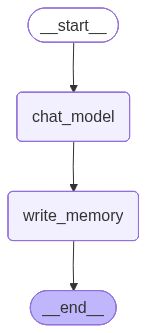

In [12]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import BaseStore
from langgraph.graph import MessagesState, StateGraph, START , END

# get runnable config to get configuration
from langchain_core.runnables import RunnableConfig


# define nodes

# chat model node
sys_inst_llm = '''You are a helpful assistant with existing memory of users. Your job is to respond to the user with accurate information. 
                     Use existing memory to personalise your response. Please follow these steps:
                     - Use only the information provided. 
                     - Do not assume or invent information. 
                     - Do not miss out information
                     - memory may be empty or doesnot exist.
                     Here is the memory : {memory}'''
def chat_model(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' Node to respond to user queries based on the meory '''
    # get memory
    user_id = config['configurable']['user_id']
    print(f"user_id: {user_id}\n")
    namespace = ("memory" , user_id)
    key = "user_profile"
    existing_memory = store.get(namespace , key)
    print(f"existing_memory: {existing_memory}\n")
    # format memory
    if existing_memory and existing_memory.value:
        memory_value = existing_memory.value
    else:
        memory_value = "No memory exists"

    # set system instruction
    sys_prompt = SystemMessage(content=sys_inst_llm.format(memory = memory_value))
    response = llm.invoke([sys_prompt] + state['messages'])
    #print(f"response form LLM: {response}")
    # update state
    return { 'messages' : [response]}

# write to or update the memory 

sys_ins_update_memory = ''' You are a helpful profiler. You have existsing memory of the users. You extract new information from the chat messages
                        given to you. review the existing memory and merge or update it with new information. If there is a confict ,
                        use latest information. Follow the rules below:
                        1.  Do not add or invent information.
                        2. do not missout or omit information from the memory as well as chat messages. Include all the important info or facts.
                        3. in case of any additional information about the user , create an additional related field (key :value pair) 
                        in the response as type(str). 
                        4. do not repeat information.
                        Here is the existing memory : {memory}'''

def write_memory(state:MessagesState , config: RunnableConfig , store:BaseStore): 
    ''' Node to write or update the existing memory store'''
    # get existing memory
    user_id = config['configurable']['user_id']
    namespace = ("memory" , user_id)
    key = "user_profile"
    existing_memory = store.get(namespace , key)
    # format 
    if existing_memory and existing_memory.value:
        
        memory_value = existing_memory.value
    else:
        memory_value = None

    # update system instruction
    sys_write_prompt = SystemMessage(content= sys_ins_update_memory.format(memory = memory_value))

    # get sturctured output
    structured_llm = llm.with_structured_output(Userprofile)
    write_response = structured_llm.invoke([sys_write_prompt] + state['messages'])
    print("write_response: ", write_response)
    # update the store
    try:
        store.put(namespace , key , write_response)
    except Exception as e: 
        print("Error writing to the store" , e)

    
# build graph
builder = StateGraph(MessagesState)

# add nodes
builder.add_node("chat_model" , chat_model)
builder.add_node("write_memory" , write_memory)

# add flow
builder.add_edge(START , "chat_model")
builder.add_edge("chat_model", "write_memory" )
builder.add_edge("write_memory", END)

# set checkpoiter and long term memory
checkpointer = MemorySaver() # thread memory
store_memory = InMemoryStore()

# build graph
graph = builder.compile(checkpointer=checkpointer , store = store_memory)

#view
from IPython.display import Image , display
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

### invoke graph


In [13]:
# provide thread_id for session memory and user_id for long term mery
config = {"configurable" : {'thread_id' : "1" , 'user_id': "1" }}

user_msg = HumanMessage(content="My name is D, I love to write novels. In my free time I go camping  and try new foods at new hangouts.")

# invoke graph streaming
for chunk in graph.stream({'messages': [user_msg] } , config, stream_mode = "updates"):
    print(chunk)

user_id: 1

existing_memory: None

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': "Hello D! It is nice to meet you. That sounds like a wonderful mix of hobbies—writing novels is such a creative pursuit, and it sounds like camping and exploring new food spots are great ways to recharge. \n\nSince I don't have any previous information about you, I have noted that you are a novelist who enjoys camping and trying new hangouts. I look forward to chatting with you more!", 'extras': {'signature': 'EjQKMgEMOdbHe0i3MdupqCBvNUP8emeIWhl7Zfshic8olRlCiSmAWK2coOCZUwubXAnFXzfm'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9e46-2ec5-7802-90cf-6519705ab1cb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 119, 'output_tokens': 83, 'total_tokens': 202, 'input_token_details': {'cache_read': 0}})]}}
write_response:  {'use

In [14]:
state_history = graph.get_state_history(config)
type(state_history)

generator

### check the store

In [12]:
memory = store_memory.search(namespace)
memory[0].value

{'user_name': 'Diya',
 'age': 40,
 'interests': ['Loves reading', 'gardening', 'Swimming']}

In [16]:
history = [m for m in state_history]
history[0]

StateSnapshot(values={'messages': [HumanMessage(content='My name is D, I love to write novels. In my free time I go camping  and try new foods at new hangouts.', additional_kwargs={}, response_metadata={}, id='867bfc99-c43a-45fe-8e16-b76c4f78f92e'), AIMessage(content=[{'type': 'text', 'text': "Hello D! It is nice to meet you. That sounds like a wonderful mix of hobbies—writing novels is such a creative pursuit, and it sounds like camping and exploring new food spots are great ways to recharge. \n\nSince I don't have any previous information about you, I have noted that you are a novelist who enjoys camping and trying new hangouts. I look forward to chatting with you more!", 'extras': {'signature': 'EjQKMgEMOdbHe0i3MdupqCBvNUP8emeIWhl7Zfshic8olRlCiSmAWK2coOCZUwubXAnFXzfm'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9e46-2ec5-7802-90cf-6519705ab1cb-0',

### continue the conversation

In [17]:
user_msg2 = HumanMessage(content="I live in state turn, tx. I'm looking for a new hobby. I love Biryani now. What restaurants in Dallas serve the best biriyani?")
# invoke graph streaming
for chunk in graph.stream({'messages': [user_msg2] } , config, stream_mode = "updates"):
    print(chunk)

user_id: 1

existing_memory: Item(namespace=['memory', '1'], key='user_profile', value={'user_name': 'D', 'age': 0, 'interests': ['writing novels', 'camping', 'trying new foods', 'exploring new hangouts'], 'additional_info': {}}, created_at='2026-06-06T18:51:10.188825+00:00', updated_at='2026-06-06T18:51:10.188825+00:00')

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'It is great to hear more about you, D! I have updated your profile to include that you live in Dallas, TX, and that you have a new love for Biryani.\n\nRegarding your request for the best Biryani in Dallas, I do not have information in my current records about specific restaurant recommendations. Since my instructions are to use only the information provided and not to invent or assume information, I am unable to suggest specific places for you to try. \n\nHowever, since you enjoy exploring new hangouts and trying new foods, I hope you find some excellent spots to enjoy your new favorite dish!'

# Check store

In [18]:
memory = store_memory.get(namespace, key)
memory.value

{'user_name': 'D',
 'age': 0,
 'interests': ['writing novels',
  'camping',
  'trying new foods',
  'exploring new hangouts'],
 'additional_info': {'location': 'Dallas, TX', 'favorite_food': 'Biryani'}}

# TrustCall
- Trustcall was built to avoid regenerating schema everytime new memory needed to be saved.
- Trust call redcuces LLM cost and removes latency
-  use `create_extractor`, passing in the model as well as our schema as a tool
-  Scema can  be JSON object / Python dictionary or Pydantic mode

### what happens under the hood?
- TrustCall uses tool calling to produce structured output from an input list of messages.
- Providing the schema name will for the `TrusCall` to produce structured output
- Create and invoke the extractor as
```
# Create the extractor
trustcall_extractor = create_extractor(
    model,
    tools=[UserProfile],
    tool_choice="UserProfile"
)
```

#### Example

In [19]:
# set Conversation list of messages
conversation = [HumanMessage(content="Hi, I'm Diya."), 
                AIMessage(content="Nice to meet you, Diya."), 
                HumanMessage(content="""Hi, I'm Diya.
I like gardening.
I live in a trailer park in San Antonio.
I have two dogs.
I'm fond of flower plants.
""")]

In [20]:
# set up  PyDantic schema with fields
from pydantic import BaseModel , Field
from typing import Dict

class UserProfile(BaseModel):
    user_name: str = Field(None, description="preferred name of the user")
    age: int = Field(None, description="age of the user")
    interests: list[str] = Field(default_factory=list, description="list of user interests")
    additionalInfo: dict[str, str] = Field(default_factory=dict, description="catches all other facts")

    

In [21]:
# create an  extractor
from trustcall import create_extractor
trustcall_extractor = create_extractor(
    llm,
    tools=[UserProfile], # schema
    tool_choice="UserProfile" # schema name
)

# system instruction for the LLM
sys_instr = SystemMessage(content="""Extract all user information from the conversation.

Rules:
1. Fill user_name, age, and interests when the information fits.
2. Any additional user facts that do NOT fit these fields must be placed in `additionalInfo` as key:value pairs.
3. Use these exact keys when applicable:
   - "location": where the user lives
   - "pets": animals the user owns
   - "shopping_intent": things the user wants to buy
4. Convert plural nouns into a comma-separated string.
5. If a sentence is unclear, extract the most reasonable interpretation.
6. Do not omit any information.
7. Do not invent information.
 """)
# invoke TrustCall - use it just like how you use `llm.with structured output(schema_name)`
result = trustcall_extractor.invoke({'messages': [sys_instr] + conversation }) # sys instr should be int he begining to advice


### TrustCall output

**When we invoke the extractor, we get a few things:**

`messages:` The list of AIMessages that contain the tool calls.

`responses: `The resulting parsed tool calls that match our schema.

`response_metadata`: Applicable if updating existing tool calls. It says which of the responses correspond to which of the existing objects.

In [22]:
result

{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'UserProfile', 'arguments': '{"interests": ["gardening", "flower plants"], "user_name": "Diya", "additionalInfo": {}}'}, '__gemini_function_call_thought_signatures__': {'7c6277aa-d40b-45ab-97c4-6123993e6847': 'EjQKMgEMOdbHS+1wX3nTLsGUwAoVOH/pCrEdUlWulJO5uweBa6AMXbtWannlgx7I/BgBDim2'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9e46-a50e-76e1-856a-8de871591269-0', tool_calls=[{'name': 'UserProfile', 'args': {'interests': ['gardening', 'flower plants'], 'user_name': 'Diya', 'additionalInfo': {}}, 'id': '7c6277aa-d40b-45ab-97c4-6123993e6847', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 308, 'output_tokens': 33, 'total_tokens': 341, 'input_token_details': {'cache_read': 0}})],
 'responses': [UserProfile(user_name='Diya', age=None, interests=['gardening', 'flower pl

In [23]:
for m in result['messages']:
    m.pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  UserProfile (7c6277aa-d40b-45ab-97c4-6123993e6847)
 Call ID: 7c6277aa-d40b-45ab-97c4-6123993e6847
  Args:
    interests: ['gardening', 'flower plants']
    user_name: Diya
    additionalInfo: {}


In [24]:
# get the schema
result['responses']

[UserProfile(user_name='Diya', age=None, interests=['gardening', 'flower plants'], additionalInfo={})]

In [25]:
#convert into dict
existing_memory = result['responses'][-1].model_dump()
existing_memory

{'user_name': 'Diya',
 'age': None,
 'interests': ['gardening', 'flower plants'],
 'additionalInfo': {}}

# if model is not following the instruction
Gemini (via LangChain):

- Does not fully support tool calling
- Does not reliably fill optional fields
- Does not create new key:value pairs
- Does not follow custom extraction rules
- Often returns empty dicts for nested fields
- This is a known limitation.

## Updating Existing Schema
### model_dump()
- To avoid sending entire profile to the model as well asking to it regenerate the memory or profile,
- ask llm to give only the 'JSON patch' that updates what has changed.
- Syntax:  `Here is the existing memory` and `here are new messages`
 ```
    result = trustcall_extractor.invoke({"messages": [SystemMessage(content=system_msg)]+updated_conversation}, 
                                        {"existing": {"UserProfile": schema[0].model_dump()}}) 
 ```
- Then TrustCall applies that patch to your existing dict.

### Pros:
- Less chance of losing fields
- Less chance of hallucinations
- Fewer tokens (only changed parts are generated)
- Less error prone
- eliminates the need to overwrite or regenerate th eentire schema
- reduces latency
### Serialize the existing profile to a dict: 

TrustCall’s update API expects the existing schema as a plain dict.
```
existing_dict = existing_profile.model_dump()
```
- Save existing schema as a dict
- use model_dump() to serialize a Pydantic model instance into a dict.
- pass it to the `"existing"` argument along with the schema name, ex: `UserProfile.`

In [26]:
# updated converstion
updated_conversation = [HumanMessage(content="Hi, I'm Diya."), 
                        AIMessage(content="Nice to meet you, Diya."), 
                        HumanMessage(content="""Hi, I'm Diya.
                                                I like gardening.
                                                I live in a trailer park in San Antonio.
                                                I have two dogs.
                                                I'm fond of flower plants.
                                                """),
                        AIMessage(content="That is amazing. do you love dogs?"),
                        HumanMessage(content="Yes. I really like biking around irving, TX."),
                        AIMessage(content="irving, TX  is a great city! Where do you go after biking?"),
                        HumanMessage(content="I really like to go to a bakery after biking."),]

# llm instruction
sys_info = f"""Update the memory (JSON doc) to incorporate new information from the following conversation. 
                review the conversation theroughly. Do not omit information"""

# Invoke the extractor with the updated instruction and existing profile with the corresponding tool name (UserProfile)
result = trustcall_extractor.invoke({"messages": [SystemMessage(content=sys_info)]+updated_conversation}, 
                                    {"existing": {"UserProfile": result['responses'][-1].model_dump()}})  
result

{'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'UserProfile', 'arguments': '{"user_name": "Diya", "additionalInfo": {}, "interests": ["gardening", "flower plants", "biking", "visiting bakeries"]}'}, '__gemini_function_call_thought_signatures__': {'88a33822-ee43-4d57-a2c4-09119295d058': 'EjQKMgEMOdbH6MjGfHU3g8xCU45XapzFVwdsOU8blsvFSZrn5iBkOsvE7YcQ8rCQ7DtkbwmK'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9e47-4998-7231-8972-fa38ec8861bc-0', tool_calls=[{'name': 'UserProfile', 'args': {'user_name': 'Diya', 'additionalInfo': {}, 'interests': ['gardening', 'flower plants', 'biking', 'visiting bakeries']}, 'id': '88a33822-ee43-4d57-a2c4-09119295d058', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 255, 'output_tokens': 45, 'total_tokens': 300, 'input_token_details': {'cache_read': 0}})],
 'responses': [UserProfile(

In [27]:
result['responses'][0].model_dump()

{'user_name': 'Diya',
 'age': None,
 'interests': ['gardening', 'flower plants', 'biking', 'visiting bakeries'],
 'additionalInfo': {}}

## Build a chatbot with Trustcall


In [75]:
from pydantic import BaseModel, Field
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END , MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import BaseStore , InMemoryStore
from langchain_core.runnables import RunnableConfig
from trustcall import create_extractor

# define schema
class userProfile(BaseModel):
    user_name: str = Field(description="Preffered name of the user")
    age :int =       Field(description="age of the user")
    interests: list[str] = Field(description =" List of users interests (example: likes, preferences, desires")
    location:str = Field(description = "location information of the user")

# create a turstCall extracter
trustcall_extractor = create_extractor(llm , 
                                          tools = [userProfile],
                                          tool_choice = "userProfile", # forces the trustcall to use this perticular schema
                                         )
llm_sys_msg = ''' You are a helpful assistant with existing memory . Your job is to respond to the user as accurately, polietly and proffessionaly.
                Use the memory as a context to personalize the response. Memory may be 'None'. Here is the memory:{memory}'''

# create a response node
def chat_model(state:MessagesState , config:RunnableConfig , store:BaseStore):
    ''' responds to user using the existing memory to personalize the response'''
    # define user ID , namespace, key
    user_id = config['configurable']['user_id']
    namespace = ('memory' , user_id)
    key = 'user_memory'

    # get existing memory
    existing_memory = store.get(namespace , key)

    # get content
    if existing_memory :
        context = existing_memory.value
    else:
        context = None
    # get response form LLM
    sys_msg = SystemMessage(content=llm_sys_msg.format(memory = context))
    response = llm.invoke([sys_msg] + state['messages'])
    return {'messages': [response]}

# write to memory 

sys_write_instruction = """Create or update the memory (JSON doc) to incorporate information from the following conversation:"""

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and save a memory to the store."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve existing memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)
        
    # Get the profile as the value from the list, and convert it to a JSON doc
    existing_profile = {"userProfile": existing_memory.value} if existing_memory else None
    
    # Invoke the extractor
    result = trustcall_extractor.invoke({"messages": [SystemMessage(content=sys_write_instruction)]+state["messages"], "existing": existing_profile})
    
    # Get the updated profile as a JSON object
    updated_profile = result["responses"][0].model_dump()

    # Save the updated profile
    #key = "user_memory"
    store.put(namespace, key, updated_profile)


## Build a graph

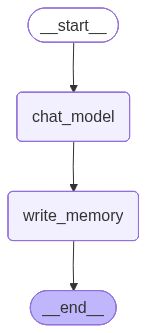

In [76]:
# define checkpointer and store memory
session_memory = MemorySaver()
store_memory = InMemoryStore()

# DEFINE BUILDER
builder = StateGraph(MessagesState)

# add nodes
builder.add_node('chat_model' , chat_model)
builder.add_node('write_memory' , write_memory)

# add flow
builder.set_entry_point('chat_model')
builder.add_edge('chat_model', 'write_memory')
builder.add_edge('write_memory', END)

# build graph
graph = builder.compile(checkpointer=session_memory , store=store_memory)

#view
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [80]:
# define thread ID for session checkpoints and user_id per user
config = {'configurable': {'thread_id':"1" , 'user_id': "1" }}

inp_msg = HumanMessage(content="Hi , My name is Diya.m im 20 yrs old")

#invoke graph
chunks = []
for chunk in graph.stream({'messages': [inp_msg]},config,stream_mode="updates"):
    chunks.append(chunk)
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': "It’s nice to meet you, Diya! Thanks for sharing that with me. How are you doing today? Is there anything specific you'd like to chat about or anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbH/hVA19znP4K9MytKLKlczTbtwZYY86V7bBQxHe1hP1l/g2UXl9VrXfTRmjUa'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9e77-b3a6-70f1-9a79-d5ab0708aa70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 98, 'output_tokens': 43, 'total_tokens': 141, 'input_token_details': {'cache_read': 0}})]}}
{'write_memory': None}


### check store

In [82]:
# set namespace and key
key = 'user_memory'
user_id = "1"
namespace = ('memory' , user_id)

memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'user_name': 'Diya',
  'age': 20,
  'interests': [],
  'location': 'unknown'},
 'created_at': '2026-06-06T19:45:06.824753+00:00',
 'updated_at': '2026-06-06T19:45:06.824753+00:00'}

### continue the conversation

In [83]:
inp_msg2 = HumanMessage(content="I live in NY. I love exploring . I am planning to visit Europe")

for chunk in graph.stream({'messages': [inp_msg2]},config, stream_mode="updates"):
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': "That sounds like an incredible plan, Diya! Europe is a fantastic place to explore, especially at 20 years old. There is so much history, culture, and variety to experience.\n\nSince you love exploring, are you looking for a fast-paced trip with lots of sightseeing, or something a bit more relaxed where you can wander through local neighborhoods? \n\nAlso, do you have any specific countries or regions in mind, or are you just starting to look at options? I'd be happy to help you brainstorm some itineraries or give you tips on how to make the most of your trip!", 'extras': {'signature': 'EjQKMgEMOdbHe9r4ztw2GKjVN4KyNfvEnRgh9QAGltcSoLjqi5As8B3vUfxYM5doXvQZGtSn'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9ea8-fb12-7d61-b5f4-659d91fcc9bd-0', tool_calls=[], invalid_tool_calls=[], us

In [84]:
memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'user_name': 'Diya',
  'age': 20,
  'interests': ['exploring', 'traveling to Europe'],
  'location': 'NY'},
 'created_at': '2026-06-06T20:39:00.480072+00:00',
 'updated_at': '2026-06-06T20:39:00.480072+00:00'}

### continue the conversation in a different thread with the smae user

In [85]:
config = {'configurable': {'thread_id':"2" , 'user_id': "1" }}

inp_msg1 = HumanMessage(content="London was amazing. I would love to find a tre3cking spot")

for chunk in graph.stream({'messages': [inp_msg1]},config, stream_mode="updates"):
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'Hi Diya! It’s so great to hear that you had an amazing time in London—it’s such a fantastic city to explore. Since I know you love traveling to Europe and are always looking for new adventures, I’d love to help you find a great trekking spot for your next trip!\n\nDepending on what kind of scenery you enjoy, here are a few iconic European trekking destinations that might pique your interest:\n\n1.  **The Tour du Mont Blanc (France, Italy, and Switzerland):** This is arguably one of the most famous long-distance treks in Europe. You get to experience three different countries, stunning alpine meadows, and dramatic mountain peaks. It’s perfect if you want a mix of culture and breathtaking nature.\n2.  **The Dolomites (Italy):** If you want dramatic, jagged limestone peaks and incredible mountain huts (*rifugios*) where you can grab a great meal after a long day of hiking, the Dolomites are hard to beat. The Alta Vi

In [86]:
memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'user_name': 'Diya',
  'age': 20,
  'interests': ['exploring', 'traveling to Europe', 'trekking'],
  'location': 'NY'},
 'created_at': '2026-06-06T20:44:01.350272+00:00',
 'updated_at': '2026-06-06T20:44:01.350272+00:00'}

### continue conversation for a different user

In [87]:
config = {'configurable': {'thread_id':"11" , 'user_id': "2" }}

inp_msg1 = HumanMessage(content="I'm James. I need a partner for bike riding and well as checking out the city London")

for chunk in graph.stream({'messages': [inp_msg1]},config, stream_mode="updates"):
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'Hello James! It’s nice to meet you. London is a fantastic city to explore, and it’s even better when you have someone to share the experience with—especially on a bike.\n\nSince I don\'t have any previous context about your preferences, I’d love to learn a bit more so I can help you get started:\n\n*   **Cycling Style:** Are you looking for casual, scenic rides through the parks (like Hyde Park or Richmond Park), or are you more interested in urban cycling and commuting routes?\n*   **Interests:** When you say "checking out the city," are you more into historical landmarks, hidden gems, food markets, or perhaps the arts and museum scene?\n*   **Finding a Partner:** Are you looking for advice on how to find local cycling clubs or social groups in London, or were you hoping I could help you plan some specific routes to suggest to potential riding buddies?\n\nThere are some great resources in London like the **Londo

### check Memory for user_id = 2 

In [89]:
# set namespace and key
key = 'user_memory'
user_id = "2"
namespace = ('memory' , user_id)

memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '2'],
 'key': 'user_memory',
 'value': {'user_name': 'James',
  'age': 0,
  'interests': ['bike riding', 'exploring London'],
  'location': 'London'},
 'created_at': '2026-06-06T20:46:23.315925+00:00',
 'updated_at': '2026-06-06T20:46:23.315925+00:00'}

# continue conversation with user 2

In [93]:
inp_msg2 = HumanMessage(content="I found Diya. Do you know her? I would like to call her")

for chunk in graph.stream({'messages': [inp_msg2]},config, stream_mode="updates"):
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'It sounds like you are excited to connect with Diya, James!\n\nTo be clear, **I do not know Diya.** As an AI, I don\'t have access to your personal life, your phone contacts, or your social media accounts, so I have no way of knowing who she is or how to reach her.\n\nAdditionally, **I cannot make phone calls for you.** My capabilities are limited to providing information and assisting with planning.\n\nIf you have her contact information from the platform where you met, here is the best way to handle this:\n\n1.  **Check the platform:** If you met her on a cycling app or a social group, check if there is a built-in messaging feature.\n2.  **Send a message first:** It is usually considered polite to send a quick text or message first to ask if she is free for a call, rather than calling her directly. You could say something like: *"Hi Diya! It’s James. I’m really looking forward to exploring London and going for 

### Check memory

In [94]:
memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '2'],
 'key': 'user_memory',
 'value': {'user_name': 'James',
  'age': 25,
  'interests': ['bike riding', 'exploring London', 'calling Diya'],
  'location': 'London'},
 'created_at': '2026-06-06T20:50:47.404687+00:00',
 'updated_at': '2026-06-06T20:50:47.404687+00:00'}

### continue the ocnversation in a different session

In [95]:
config = {'configurable': {'thread_id':"12" , 'user_id': "2" }}

inp_msg1 = HumanMessage(content="Diya is Jpinign me. WE are going for camping")

for chunk in graph.stream({'messages': [inp_msg1]},config, stream_mode="updates"):
    print(chunk)

{'chat_model': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'That sounds like a fantastic plan, James! It’s great that Diya is joining you—I know how much you enjoy catching up with her.\n\nSince you are based in London and enjoy bike riding and exploring, are you heading somewhere nearby for your camping trip, or are you venturing a bit further out? I hope you both have a wonderful time!', 'extras': {'signature': 'EjQKMgEMOdbHC+ky+tUabpnoVASDwFHp2lUvU3NZNVE7Hbb3F2Mgv3Thz1zJyWb4muXGTDDy'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e9eb4-f863-7362-8955-0a70d858d651-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 104, 'output_tokens': 73, 'total_tokens': 177, 'input_token_details': {'cache_read': 0}})]}}
{'write_memory': None}


# check store

In [96]:
memory = store_memory.get(namespace , key)
memory.dict()

{'namespace': ['memory', '2'],
 'key': 'user_memory',
 'value': {'user_name': 'James',
  'age': 25,
  'interests': ['bike riding',
   'exploring London',
   'calling Diya',
   'camping with Diya'],
  'location': 'London'},
 'created_at': '2026-06-06T20:52:24.963840+00:00',
 'updated_at': '2026-06-06T20:52:24.963840+00:00'}